# Final Response Evaluation Analysis

This notebook visualizes the performance of the search agent variants (`V0` to `V4`) based on the final LLM-as-a-judge scores.

### Experimental Variants Breakdown:
- **V0 (Generic Single):** Searches 1 generic query. Synthesizes a generic answer (no persona given).
- **V1 (Generic Fanout):** Searches 4 generic branches. Synthesizes a generic answer (no persona given).
- **V2 (Synthesis-Only Personalization):** Searches 4 generic branches. Synthesizes a personalized answer (persona given at the very end).
- **V3 (Personalized Fanout):** Searches 4 personalized branches. Synthesizes a personalized answer.
- **V4 (Mixed Fanout):** Searches 2 generic and 2 personalized branches. Synthesizes a personalized answer.

### Metrics Evaluated:
- **Intent Satisfaction:** Did the agent fulfill the hidden intent? (Higher is better)
- **Personalization Target Use:** Did the agent use the required user facts? (Higher is better)
- **Overpersonalization:** Did the agent force irrelevant details? (Lower is better)
- **Overall:** Holistic quality score. (Higher is better)

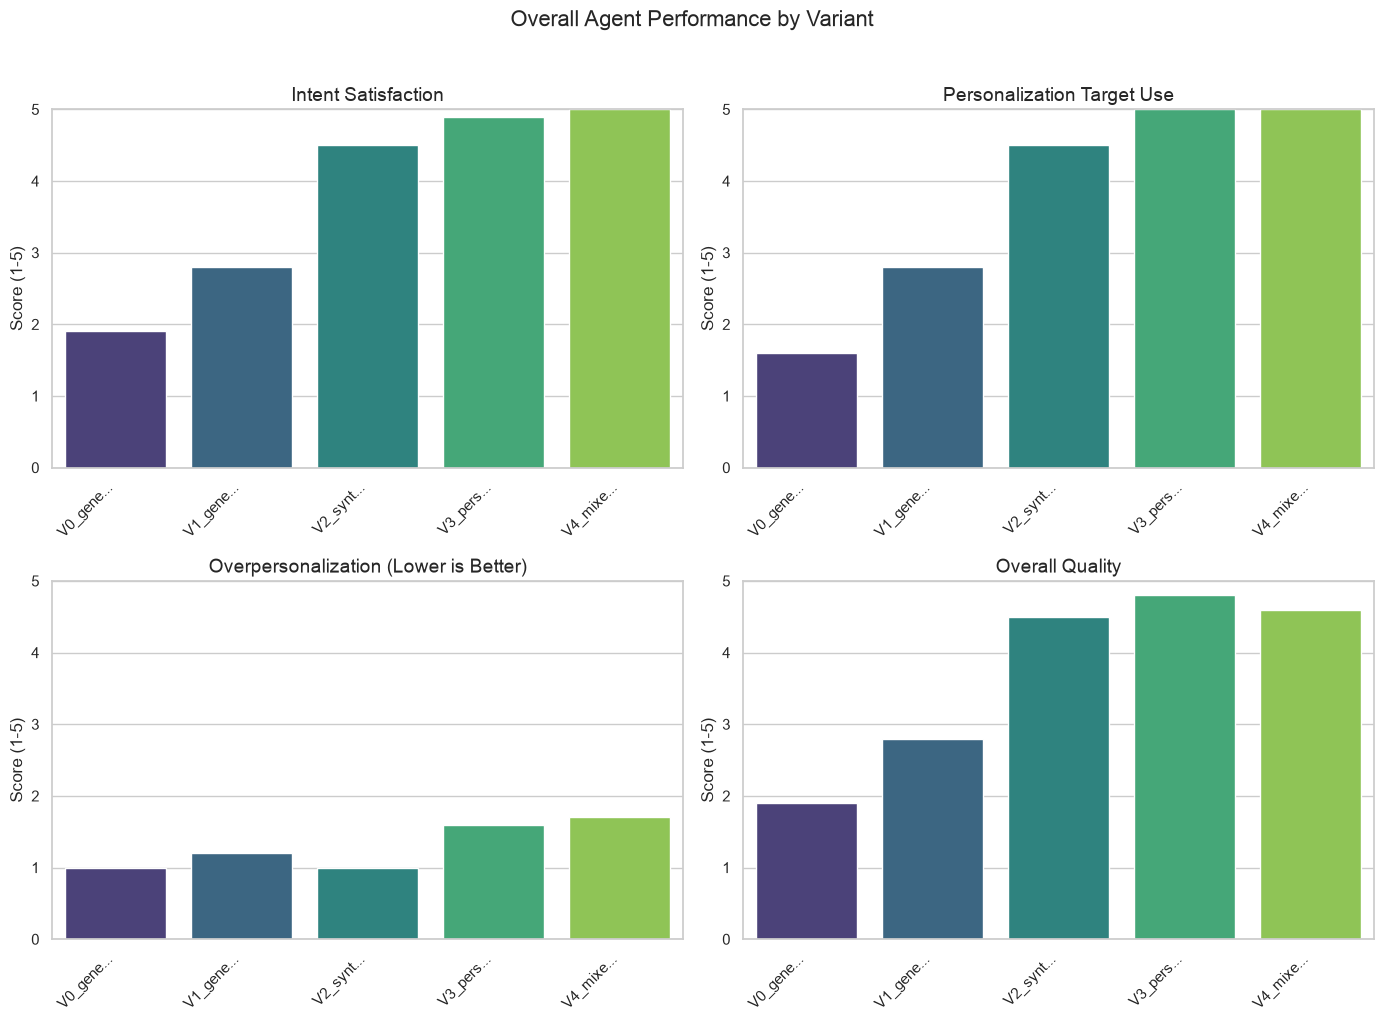

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the overall summary by variant
df_variant = pd.read_csv("experiments/evaluation/generated/summary_by_variant.csv")
df_query_type = pd.read_csv("experiments/evaluation/generated/summary_by_variant_query_type.csv")

# Set aesthetic style
sns.set_theme(style="whitegrid")

# Create a figure for overall metrics
metrics = ['mean_intent_satisfaction', 'mean_personalization_target_use', 'mean_overpersonalization', 'mean_overall']
titles = ['Intent Satisfaction', 'Personalization Target Use', 'Overpersonalization (Lower is Better)', 'Overall Quality']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Overall Agent Performance by Variant', fontsize=16, y=1.02)


for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    # Fixed FutureWarning: added hue='variant' and legend=False
    sns.barplot(data=df_variant, x='variant', y=metric, ax=ax, palette='viridis', hue='variant', legend=False)
    ax.set_title(title, fontsize=14)
    # Define ticks first to avoid UserWarning
    ax.set_xticks(range(len(df_variant['variant'])))
    # Shorten variant names for readability on x-axis
    ax.set_xticklabels([v.split('_')[0] + '_' + v.split('_')[1][:4] + '...' for v in df_variant['variant']], rotation=45, ha='right')
    ax.set_ylim(0, 5)
    ax.set_xlabel("")
    ax.set_ylabel("Score (1-5)")

plt.tight_layout()
plt.show()

In [ ]:
# Plot breakdown by query type for Overall Quality
plt.figure(figsize=(12, 6))
sns.barplot(data=df_query_type, x='variant', y='mean_overall', hue='query_type', palette='magma')
plt.title('Overall Quality by Variant and Query Ambiguity Type', fontsize=16)

# Shorten variant names on the x-axis
short_variants = [v.split('_')[0] + '_' + v.split('_')[1][:4] + '...' for v in df_query_type['variant'].unique()]
plt.xticks(ticks=range(len(short_variants)), labels=short_variants, rotation=45, ha='right')

plt.ylim(0, 5)
plt.ylabel('Overall Score (1-5)')
plt.xlabel('')
plt.legend(title='Query Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Conclusion & Key Findings

Based on the evaluation data across the generated queries, we observe strong positive signals for injecting personalization into the search agent pipeline:

1. **Late-Stage Personalization is Highly Effective (V2 vs V1):** Simply providing the user's persona to the final LLM synthesizer *without* modifying the underlying search queries (V2) results in a massive jump in intent satisfaction. It allows the agent to extract highly relevant, personalized answers from generic search results.
2. **Early-Stage Personalization Maximizes Specificity (V3 vs V2):** Pushing personalization upstream into the web search queries themselves (V3) yields the absolute highest scores for intent satisfaction and specificity. By proactively hunting for constraints (e.g., specific allergies or budgets), the agent retrieves highly tailored evidence. While this aggressive strategy results in a slight uptick in the overpersonalization metric, it strongly guarantees that the user's most critical requirements and intent are fully addressed in the final response.

## Qualitative Analysis: A Step-by-Step Example

To understand exactly *why* the data shows V3 > V2 > V0 for intent satisfaction, let's look at a concrete example from the generated benchmark logs.

**Ambiguous User Query:** `"best way to learn database design"`
**Persona Hidden Intent:** *Find self-paced, low-cost (non-bootcamp), syntax-heavy, and project-based tutorials/courses for learning relational database design from first principles, preferably using Python and PostgreSQL.*

### V0: Generic Single (Score: 2/5)
*The agent searches generically and synthesizes without the persona.*
The response is highly generic. It suggests broad concepts (OLTP vs OLAP) and recommends generic academic college routes or broad paid platforms like DataCamp/Coursera. It completely misses the user's specific need for free, syntax-heavy, Python-based, or self-paced project learning.

> **Excerpt from V0 Response:**
> "As you progress, expand your knowledge into different database methodologies depending on your goals: Learn the differences between OLTP and OLAP (according to DataCamp)... Utilize Recommended Learning Resources: Use free or low-cost platforms like Khan Academy, Coursera, DataCamp... If you are looking for a highly structured, academic approach, pursuing a major or courses in Information Systems is one of the most direct ways to build these skills."

### V2: Synthesis-Only Personalization (Score: 4/5)
*The agent searches generically, but the LLM synthesizes using the persona.*
The response improves dramatically. It correctly filters the generic search results to highlight "self-paced," "free," and "syntax-heavy" resources (like the freeCodeCamp YouTube course and free textbooks). However, because the underlying web search was generic, it failed to retrieve any evidence specifically linking database design with *Python and PostgreSQL*. 

> **Excerpt from V2 Response:**
> "The best way to learn database design is through a structured, self-paced path that combines first-principles relational theory with hands-on, project-based practice... Utilize Free, High-Quality Courses: You do not need an expensive bootcamp to learn database design. Several comprehensive, self-paced resources are freely available: freeCodeCamp’s Relational Database Design Course... Read Practical, Ground-Up Textbooks: 'Database Design - 2nd Edition' (Open Textbook Library)."

### V3: Personalized Fanout (Score: 5/5)

*The agent searches using personalized queries and synthesizes using the persona.*
**The exact search queries V3 ran:**
- `self paced database design course first principles`
- `database design for python data engineering tutorials`
- `project based database modeling SQL tutorials`
- `learn relational database design postgresql linux`

The response is perfect. Because the web search itself was instructed to hunt for Python and PostgreSQL integration, the final answer explicitly recommends setting up a local PostgreSQL environment, connecting via `psycopg2` or `SQLAlchemy` in Python, and writing Python ETL pipelines to populate the local schemas. 

> **Excerpt from V3 Response:**
> "The best way to learn database design is through a self-paced, project-based approach... Set Up a Local, Open-Source Environment: If you are using a Linux-based operating system, PostgreSQL is highly recommended... Integrate with Python: If your ultimate goal involves data analytics or data engineering, you should learn how to programmatically interact with your designed databases using Python. Database Connections: Learn how to connect Python to your local PostgreSQL database using libraries like `psycopg2` or SQLAlchemy. ETL Pipelines: Practice writing Python scripts to extract data from flat files..."

**Takeaway:** This level of extreme, highly-tailored specificity (V3) is physically impossible to achieve in V2, because the generic web search simply never retrieved the niche Python/PostgreSQL evidence for the LLM to synthesize.